In [1]:
import os, copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

In [2]:
IMG_SIZE   = 64
BATCH_SIZE = 32
LATENT_DIM = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# load data
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")
dataset_path = os.path.join(path, "Celebrity Faces Dataset")

records = []
for celebrity in sorted(os.listdir(dataset_path)):
    celeb_dir = os.path.join(dataset_path, celebrity)
    if not os.path.isdir(celeb_dir):
        continue
    for img_file in os.listdir(celeb_dir):
        if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "identity": celebrity,
                "filepath": os.path.join(celeb_dir, img_file)
            })

df = pd.DataFrame(records)
identity_names = sorted(df["identity"].unique())
name_to_label  = {name: i for i, name in enumerate(identity_names)}
df["label"]    = df["identity"].map(name_to_label)

print(f"Total images: {len(df)}")
print(f"Images per celebrity:\n{df['identity'].value_counts()}")

100%|██████████| 52.9M/52.9M [00:00<00:00, 113MB/s] 

Extracting files...


Total images: 1800
Images per celebrity:
identity
Scarlett Johansson    200
Angelina Jolie        100
Brad Pitt             100
Hugh Jackman          100
Denzel Washington     100
Johnny Depp           100
Kate Winslet          100
Leonardo DiCaprio     100
Jennifer Lawrence     100
Megan Fox             100
Natalie Portman       100
Robert Downey Jr      100
Nicole Kidman         100
Sandra Bullock        100
Tom Cruise            100
Tom Hanks             100
Will Smith            100
Name: count, dtype: int64


In [4]:
# forget/retain set
forget_celebrity = identity_names[0]
print(f"Forget target: {forget_celebrity}")

forget_df = df[df["identity"] == forget_celebrity].reset_index(drop=True)
retain_df = df[df["identity"] != forget_celebrity].reset_index(drop=True)

print(f"Forget set: {len(forget_df)} images")
print(f"Retain set: {len(retain_df)} images")

Forget target: Angelina Jolie
Forget set: 100 images
Retain set: 1700 images


In [5]:
# dataset + dataloaders
class CelebDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label, autoencoder doesn't use it

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

forget_dataset = CelebDataset(forget_df, transform)
retain_dataset  = CelebDataset(retain_df, transform)
full_dataset    = ConcatDataset([forget_dataset, retain_dataset])

forget_loader = DataLoader(forget_dataset, batch_size=BATCH_SIZE, shuffle=True)
retain_loader  = DataLoader(retain_dataset,  batch_size=BATCH_SIZE, shuffle=True)
full_loader    = DataLoader(full_dataset,    batch_size=BATCH_SIZE, shuffle=True)

print(f"Forget batches: {len(forget_loader)} | Retain batches: {len(retain_loader)}")

Forget batches: 4 | Retain batches: 54


In [6]:
# ae model
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64→32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32→16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16→8
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# 8→4
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc_enc  = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_dec  = nn.Linear(latent_dim, 256 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.fc_enc(self.flatten(self.encoder(x)))
        decoded = self.decoder(self.fc_dec(encoded).view(-1, 256, 4, 4))
        return decoded

ae_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(f"Autoencoder params: {sum(p.numel() for p in ae_model.parameters()):,}")

Autoencoder params: 2,432,835


In [8]:
# original model on all celebs
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

def train_autoencoder(model, loader, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, _ in loader:
            images = images.to(device)
            loss   = criterion(model(images), images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.5f}")

train_autoencoder(ae_model, full_loader, epochs=10)

os.makedirs("models", exist_ok=True)
torch.save(ae_model.state_dict(), "models/AE_orig.pt")
print("Saved AE_orig.pt")

Epoch 1/10 | Loss: 0.06695
Epoch 2/10 | Loss: 0.03804
Epoch 3/10 | Loss: 0.03063
Epoch 4/10 | Loss: 0.02750
Epoch 5/10 | Loss: 0.02430
Epoch 6/10 | Loss: 0.02237
Epoch 7/10 | Loss: 0.02013
Epoch 8/10 | Loss: 0.01863
Epoch 9/10 | Loss: 0.01715
Epoch 10/10 | Loss: 0.01638
Saved AE_orig.pt


BEFORE — Forget MSE: 0.01458 | Retain MSE: 0.01536


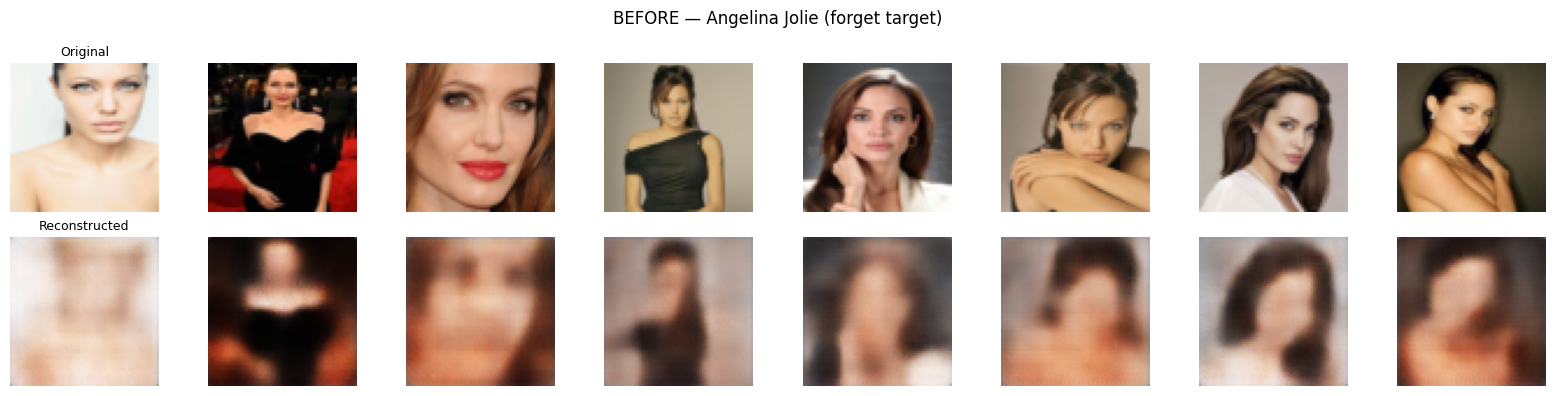

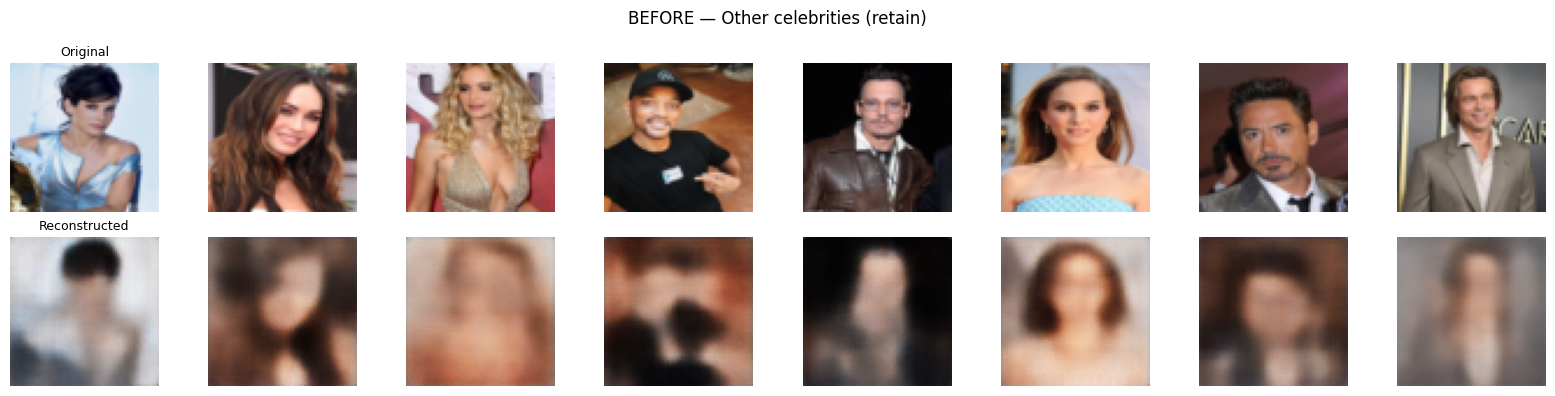

In [9]:
# baseline matrics + initial visualizations
def compute_mse(model, loader):
    model.eval()
    total, count = 0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            total += criterion(model(images), images).item() * images.size(0)
            count += images.size(0)
    return total / count

def show_reconstructions(model, loader, title="", n=8):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    with torch.no_grad():
        recons = model(images)
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0,i].imshow(images[i].cpu().permute(1,2,0).clamp(0,1))
        axes[0,i].axis('off')
        axes[1,i].imshow(recons[i].cpu().permute(1,2,0).clamp(0,1))
        axes[1,i].axis('off')
    axes[0,0].set_title('Original', fontsize=9)
    axes[1,0].set_title('Reconstructed', fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

forget_mse_before = compute_mse(ae_model, forget_loader)
retain_mse_before  = compute_mse(ae_model, retain_loader)
print(f"BEFORE — Forget MSE: {forget_mse_before:.5f} | Retain MSE: {retain_mse_before:.5f}")

show_reconstructions(ae_model, forget_loader, title=f"BEFORE — {forget_celebrity} (forget target)")
show_reconstructions(ae_model, retain_loader, title="BEFORE — Other celebrities (retain)")